<a href="https://colab.research.google.com/github/Devil-92/100_Days_of_ML/blob/main/FeatureSelection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> The simplest form of selecting features would be to remove features with very
low variance. If the features have a very low variance (i.e. very close to 0), they
are close to being constant and thus, do not add any value to any model at all. It
would just be nice to get rid of them and hence lower the complexity. Please note
that the variance also depends on scaling of the data. Scikit-learn has an
implementation for VarianceThreshold that does precisely this.

In [36]:
import pandas as pd

In [37]:
from sklearn.feature_selection import VarianceThreshold
from sklearn import datasets

data = datasets.fetch_california_housing()
X = data.data
y = data.target
col_names = data['feature_names']
df = pd.DataFrame(
    X ,
    columns = col_names
)
var_thresh = VarianceThreshold(threshold = 0.00002)
transformed_data = var_thresh.fit_transform(df)
# transformed data will have all columns with variance less than threshold removed

In [38]:
transformed_data

array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]])

>We can also remove features which have a high correlation. For calculating the
correlation between different numerical features, you can use the Pearson
correlation

In [39]:
import numpy as np

In [40]:
df['Sqrt_Inc'] = df['MedInc'].apply(np.sqrt)

In [41]:
df.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Sqrt_Inc
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.984329
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,-0.132797
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.326688
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.066910
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,0.018415
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,0.015266
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.084303
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.015569
Sqrt_Inc,0.984329,-0.132797,0.326688,-0.066910,0.018415,0.015266,-0.084303,-0.015569,1.000000


In [42]:
print('We can see the correction and remove one of the column')

We can see the correction and remove one of the column


>And now we can move to some univariate ways of feature selection. Univariate
feature selection is nothing but a scoring of each feature against a given target.
Mutual information, ANOVA F-test and chi2 are some of the most popular
methods for univariate feature selection.

 > Here are two ways of using these in scikit-
learn.
- SelectKBest: It keeps the top-k scoring features
- SelectPercentile: It keeps the top features which are in a percentage
specified by the user

It must be noted that you can use chi2 only for data which is non-negative in nature.
This is a particularly useful feature selection technique in natural language
processing when we have a bag of words or tf-idf based features. It’s best to create
a wrapper for univariate feature selection that you can use for almost any new
problem.

F-tests assume linear and MI is nonparametric but noisier

In [43]:
from sklearn.feature_selection import chi2
from sklearn.feature_selection import f_classif
from sklearn.feature_selection import f_regression
from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_selection import mutual_info_regression
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import SelectPercentile

In [44]:
class UnivariateFeatureSelection :
  def __init__(self , n_features , problem_type , scoring) :

    if problem_type == 'classification' :
      valid_scoring = {
          'f_classif' : f_classif ,
          'chi2' : chi2 ,
          'mutual_info_classif' : mutual_info_classif
      }

    else :
      valid_scoring = {
          'f_regression' : f_regression ,
          'mutual_info_regression' : mutual_info_regression
      }

    if scoring not in valid_scoring :
      raise Exception('Invalid Scoring function')

    if isinstance(n_features , int) :
      self.Selection = SelectKBest(
          valid_scoring[scoring] ,
          k = n_features
      )
    elif isinstance(n_features , float) :
      self.Selection = SelectPercentile(
          valid_scoring[scoring] ,
          percentile = int(n_features * 100)
      )

  def fit(self , X , y) :
      return self.Selection.fit(X , y)

  def transform(self , X) :
      return self.Selection.transform(X)

  def fit_transform(self , X , y) :
      return self.Selection.fit_transform(X , y)

In [45]:
ufs = UnivariateFeatureSelection(
    n_features = 0.1 ,
    problem_type = 'regression' ,
    scoring = 'f_regression'
)

ufs.fit(X,y)

X_transformed = ufs.transform(X)

In [46]:
X_transformed

array([[8.3252],
       [8.3014],
       [7.2574],
       ...,
       [1.7   ],
       [1.8672],
       [2.3886]])

>  Univariate feature selection may not always perform
well. Most of the time, people prefer doing feature selection using a machine
learning model.

> The simplest form of feature selection that uses a model for selection is known as
greedy feature selection. In greedy feature selection, the first step is to choose a
model. The second step is to select a loss/scoring function. And the third and final
step is to iteratively evaluate each feature and add it to the list of “good” features if it improves loss/score. It can’t get simpler than this. But you must keep in mind that
this is known as greedy feature selection for a reason. This feature selection process
will fit a given model each time it evaluates a feature. The computational cost
associated with this kind of method is very high. It will also take a lot of time for
this kind of feature selection to finish. And if you do not use this feature selection
properly, then you might even end up overfitting the model

In [47]:
! pwd

/content


In [48]:
! mkdir src

mkdir: cannot create directory ‘src’: File exists


In [49]:
! pwd

/content


In [50]:
! cd '/content/src'

In [51]:
import os
open('greedy.py' , 'a').close()

In [52]:
%%writefile greedy.py
import pandas as pd

from sklearn import linear_model
from sklearn import metrics
from sklearn.datasets import make_classification

class GreedyFeatureSelection:

  def evaluate_score(self , X , y) :

    model = linear_model.LogisticRegression()

    model.fit(X , y)

    predictions = model.predict_proba(X)[: , 1]

    auc = metrics.roc_auc_score(y , predictions)

    return auc

  def _feature_selection(self , X , y) :

    good_features = []
    best_scores = []

    num_features = X.shape[1]

    while True :

      this_feature = None
      best_score = 0

      for feature in range(num_features) :

        if feature in good_features :
          continue

        selected_features = good_features + [feature]

        xtrain = X[: , selected_features]

        score = self.evaluate_score(xtrain , y)

        if score > best_score :
          this_feature = feature
          best_score = score

      if this_feature != None :
        good_features.append(this_feature)
        best_scores.append(best_score)

      if len(best_scores) > 2 :
        if best_scores[-1] < best_scores[-2] :
          break

    return best_scores[: -1] , good_features[: -1]

    def __call__(self , X , y) :

      scores , features = self._feature_selection(X , y)

      return X[: , features] , scores

    if __name__ == '__main__' :

      X , y = make_classification(n_samples = 1000 , n_features = 100)

      X_transformed , scores = GreedyFeatureSelection()(X , y)

Overwriting greedy.py


In [53]:
! python greedy.py

In [54]:
X_transformed

array([[8.3252],
       [8.3014],
       [7.2574],
       ...,
       [1.7   ],
       [1.8672],
       [2.3886]])

>Another greedy approach is known as recursive feature elimination (RFE). In the
previous method, we started with one feature and kept adding new features, but in
RFE, we start with all features and keep removing one feature in every iteration that
provides the least value to a given model. But how to do we know which feature
offers the least value? Well, if we use models like linear support vector machine
(SVM) or *logistic regression*, we get a coefficient for each feature which decides
the importance of the features. In case of any tree-based models, we get feature
importance in place of coefficients. In each iteration, we can eliminate the least important feature and keep eliminating it until we reach the number of features
needed. So, yes, we have the ability to decide how many features we want to keep.

>When we are doing recursive feature elimination, in each iteration, we remove the
feature which has the feature importance or the feature which has a coefficient
close to 0. Please remember that when you use a model like logistic regression for
binary classification, the coefficients for features are more positive if they are
important for the positive class and more negative if they are important for the
negative class. It’s very easy to modify our greedy feature selection class to create
a new class for recursive feature elimination, but scikit-learn also provides RFE
out of the box.

In [56]:
import pandas as pd
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing()
X = data.data
y = data.target
col_names = data['feature_names']

model = LinearRegression()

rfe = RFE(
    estimator = model ,
    n_features_to_select = 3
)

rfe.fit(X , y)

X_transformed = rfe.transform(X)

>We saw two different greedy ways to select features from a model. But you can also
fit the model to the data and select features from the model by the feature
coefficients or the importance of features. If you use coefficients, you can select
a threshold, and if the coefficient is above that threshold, you can keep the feature
else eliminate it

In [58]:
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.ensemble import RandomForestClassifier

data = load_diabetes()
X = data.data
col_names = data['feature_names']
y = data.target

model = RandomForestClassifier()

model.fit(X , y)

RandomForestClassifier()

In [61]:
import matplotlib.pyplot as plt

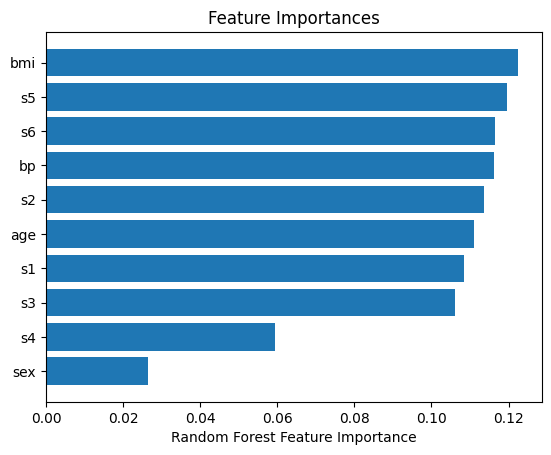

In [64]:
importance = model.feature_importances_
idxs = np.argsort(importance)
plt.title('Feature Importances')
plt.barh(range(len(idxs)), importance[idxs], align='center')
plt.yticks(range(len(idxs)), [col_names[i] for i in idxs])
plt.xlabel('Random Forest Feature Importance')
plt.show()

>Well, selecting the best features from the model is nothing new. You can choose
features from one model and use another model to train. For example, you can use
Logistic Regression coefficients to select the features and then use Random Forest
to train the model on chosen features. Scikit-learn also offers SelectFromModel
class that helps you choose features directly from a given model. You can also
specify the threshold for coefficients or feature importance if you want and the
maximum number of features you want to select

In [65]:
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel

data = load_diabetes()
X = data["data"]
col_names = data["feature_names"]
y = data["target"]

model = RandomForestRegressor()

sfm = SelectFromModel(estimator=model)
X_transformed = sfm.fit_transform(X, y)

support = sfm.get_support()

print([x for x, y in zip(col_names, support) if y == True])

['bmi', 's5']


>Thus, we could have also selected directly from feature importance
provided by random forest. One more thing that we are missing here is feature
selection using models that have L1 (Lasso) penalization. When we have L1
penalization for regularization, most coefficients will be 0 (or close to 0), and we
select the features with non-zero coefficients